In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob

In [23]:
path='./Data/*.txt'
files=sorted(glob.glob(path))
col_list = ['SquareID', 'TimeInterval', 'CountryCode', 'SmsIn', 'SmsOut', 'CallIn', 'CallOut', 'Internet']
data_frames = []
for file in files:
    temp_df = pd.read_csv(file, sep='\t', header=None, names=col_list, usecols=[0, 1, 7])
    temp_df = temp_df.dropna(subset=['Internet'])
    temp_df['TimeInterval'] = pd.to_datetime(temp_df['TimeInterval'], unit='ms')
    data_frames.append(temp_df)
data = pd.concat(data_frames, ignore_index=True)


In [24]:
#task2
statistics=data['Internet'].describe()
median=data['Internet'].median()
empty=data.isnull().sum()
print("Statistics")
print(f"Mean: {statistics['mean']:.2f}")
print(f"Median: {median:.2f}")
print(f"Empty Values:\n {empty}")
print(f"Standard Deviation: {statistics['std']:.2f}")
print(f"Minimum: {statistics['min']:.2f}")
print(f"Maximum: {statistics['max']:.2f}")

Statistics
Mean: 36.93
Median: 3.69
Empty Values:
 SquareID        0
TimeInterval    0
Internet        0
dtype: int64
Standard Deviation: 104.05
Minimum: 0.00
Maximum: 7936.27


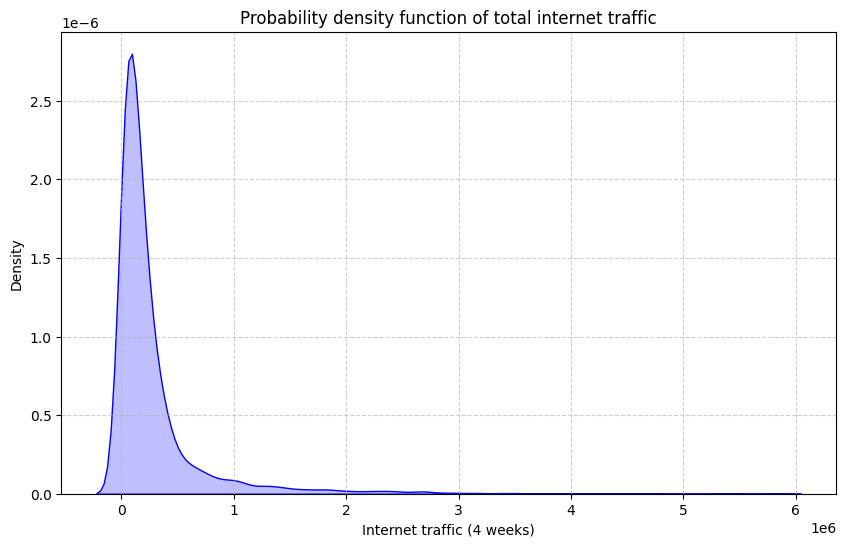

In [25]:
#task3
internet_traffic = data.groupby('SquareID')['Internet'].sum()
plt.figure(figsize=(10, 6))
sns.kdeplot(internet_traffic, fill=True, color='blue')
plt.title('Probability density function of total internet traffic')
plt.xlabel('Internet traffic (4 weeks)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

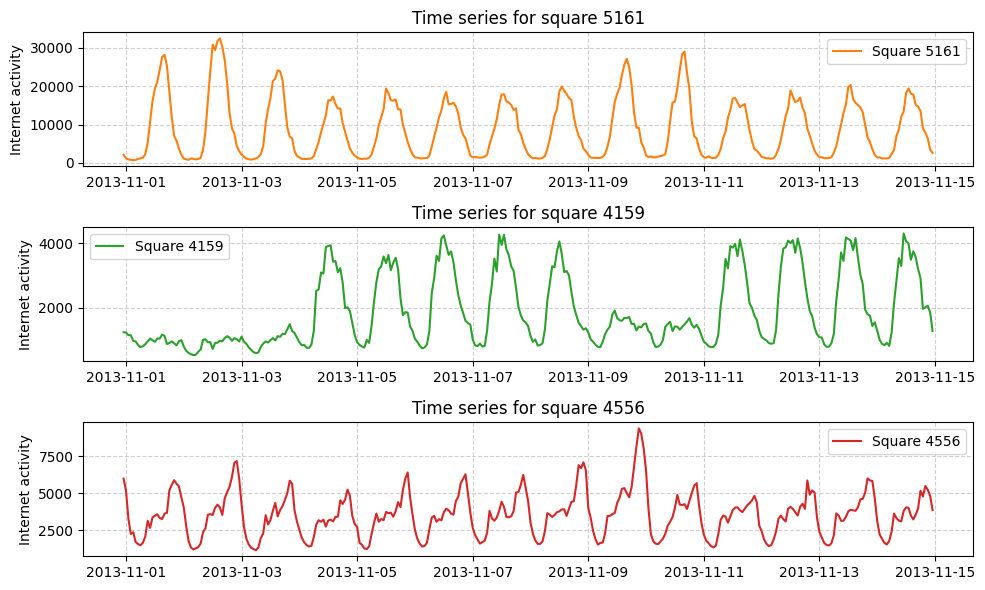

In [26]:
#task4
top_square_id = data.groupby('SquareID')['Internet'].sum().idxmax()
target_ids = [top_square_id, 4159, 4556]
TwoWeeks = data[data['TimeInterval'] < '2013-11-15']
plot_data = TwoWeeks[TwoWeeks['SquareID'].isin(target_ids)]
plt.figure(figsize=(10, 6))
for i, grid in enumerate(target_ids, 1):
    subset = TwoWeeks[TwoWeeks['SquareID'] == grid].copy()
    hourly_subset = subset.set_index('TimeInterval').resample('h')['Internet'].sum()
    plt.subplot(3, 1, i)
    plt.plot(hourly_subset.index, hourly_subset.values, label=f'Square {grid}', color='C'+str(i))
    plt.title(f'Time series for square {grid}')
    plt.ylabel('Internet activity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

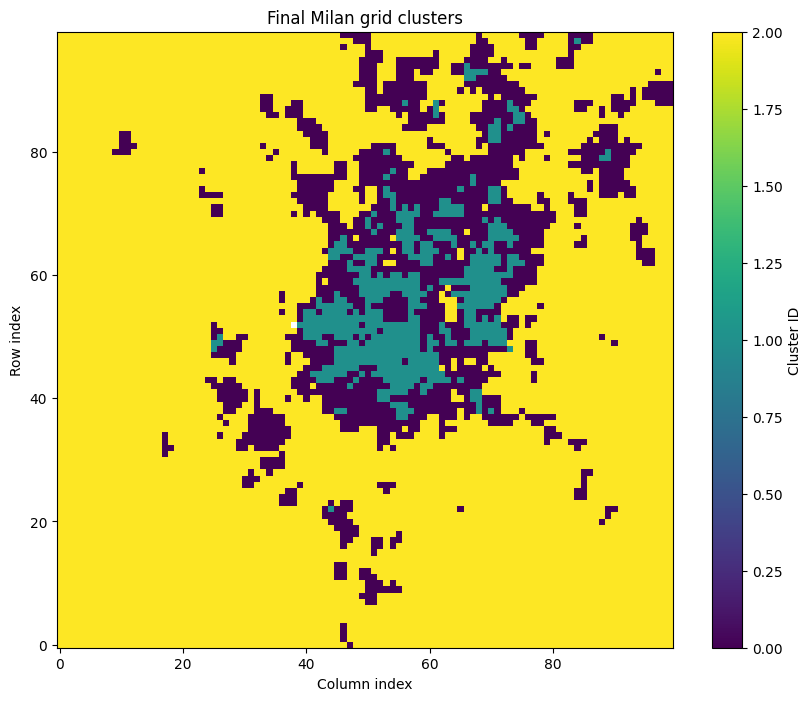

In [27]:
import json
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data['DayOfWeek'] = data['TimeInterval'].dt.dayofweek
data['Hour'] = data['TimeInterval'].dt.hour
weekly_profiles = data.groupby(['SquareID', 'DayOfWeek', 'Hour'])['Internet'].mean().unstack(level=[1, 2])
weekly_profiles_clean = weekly_profiles.dropna()
scaler = StandardScaler()
scaled_profiles = scaler.fit_transform(weekly_profiles_clean)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_profiles)

with open('milano-grid.geojson', 'r') as f:
    grid_data = json.load(f)

grid_map = np.full((100, 100), np.nan)
cluster_dict = dict(zip(weekly_profiles_clean.index, clusters))

for feature in grid_data['features']:
    grid_id = feature['properties']['cellId']
    if grid_id in cluster_dict:
        row = (grid_id - 1) // 100
        col = (grid_id - 1) % 100
        grid_map[row, col] = cluster_dict[grid_id]

plt.figure(figsize=(10, 8))
plt.imshow(grid_map, cmap='viridis', origin='lower')
plt.colorbar(label='Cluster ID')
plt.title('Final Milan grid clusters')
plt.xlabel('Column index')
plt.ylabel('Row index')
plt.show()

Top 10 anomalous square IDs:
[5161, 6370, 5061, 5159, 7724, 5059, 6371, 5259, 6372, 4459]


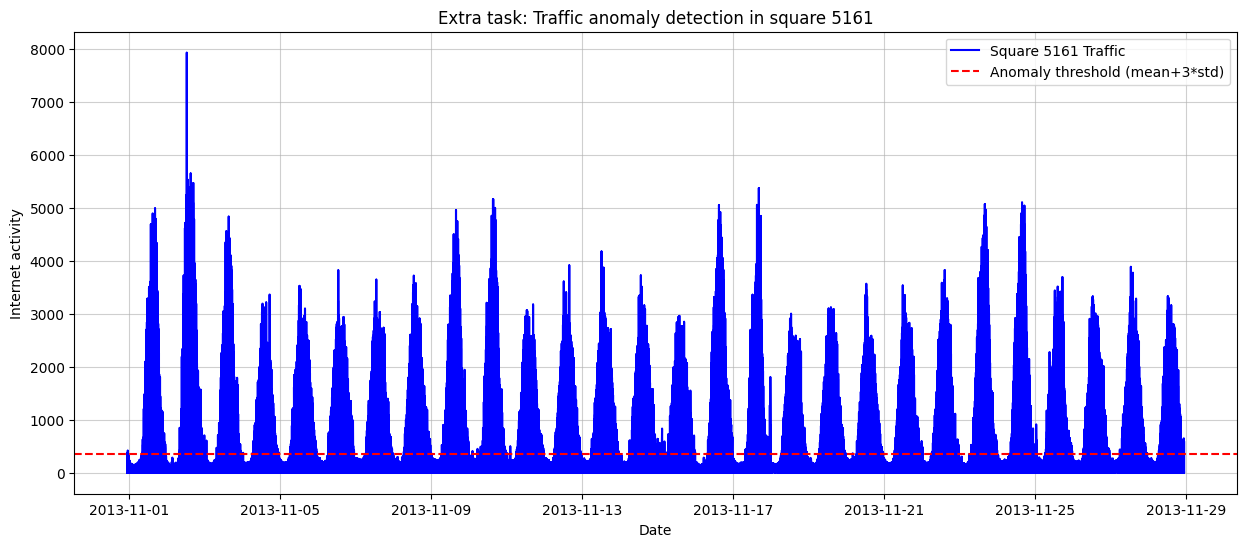

In [30]:
#taskextra
mean_val = data['Internet'].mean()
std_val = data['Internet'].std()

data['z_score'] = (data['Internet'] - mean_val) / std_val
top_anomalies = data.sort_values(by='z_score', ascending=False).drop_duplicates('SquareID').head(10)
top_10_ids = top_anomalies['SquareID'].tolist()

print("Top 10 anomalous square IDs:")
print(top_10_ids)
target_id = top_10_ids[0]
anomaly_series = data[data['SquareID'] == target_id].sort_values('TimeInterval')

plt.figure(figsize=(15, 6))
plt.plot(anomaly_series['TimeInterval'], anomaly_series['Internet'], label=f'Square {target_id} Traffic', color='blue')
plt.title(f'Extra task: Traffic anomaly detection in square {target_id}')
plt.axhline(mean_val + 3*std_val, color='red', linestyle='--', label='Anomaly threshold (mean+3*std)')
plt.xlabel('Date')
plt.ylabel('Internet activity')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()